# EconomIA — Resumen financiero mensual

Este notebook integra:

```text
                    users.csv + transactions.csv
                              ↓
monthly_financial_summary.csv + monthly_model_dataset.csv
```

El objetivo es crear una fila por **usuario y mes**, calcular indicadores financieros y asignar un perfil mediante un scoring explicable.

### Decisiones del proyecto:

- `meta_ahorro` representa la meta declarada por el usuario
- El ahorro real se calcula con las transacciones
- `arquetipo_comportamiento` no se integra al resumen mensual ni al dataset de modelos
- El perfil financiero se obtiene con reglas sobre gasto, ahorro, deuda, balance y control del gasto
- Se generan dos archivos:
  - `monthly_financial_summary.csv`: resumen completo y explicable
  - `monthly_model_dataset.csv`: versión sin las columnas del scoring para reducir fuga de información.


Para cada usuario y cada mes se calcula:

- Ingresos:
  - Ingreso total
  - Ingreso base
  - Ingreso variable
- Gastos:
  - Gasto total
  - Gasto por categoría
  - Porcentaje por categoría
- Ahorro:
  - Ahorro mensual
  - Tasa de ahorro
- Deuda
  - Pagos de deuda
  - Porcentaje destinado a deuda
- Comportamiento
  - Número de transacciones
  - Gastos recurrentes
  - Concentración de gastos
  - Balance mensual
- Indicadores
  - Tasa de gasto
  - Tasa de ahorro
  - Tasa de endeudamiento
  - Balance positivo/negativo

In [ ]:
# =========
# LIBRERÍAS
# =========

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Carga de archivos

La función busca primero los archivos en Colab, después en `/mnt/data` y finalmente en la carpeta actual.


In [ ]:
# =================================================
# FUNCIÓN PARA UBICAR ARCHIVOS DE MANERA AUTOMÁTICA
# =================================================

def find_file(file_name):

    possible_paths = [Path("/content") / file_name,Path("/mnt/data") / file_name,Path(file_name),]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"No se encontró {file_name}. "
        "Sube el archivo al entorno antes de ejecutar el notebook."
    )


USERS_FILE = find_file("users.csv")
TRANSACTIONS_FILE = find_file("transactions.csv")

OUTPUT_DIR = Path("/content") if Path("/content").exists() else Path("/mnt/data")

print("Usuarios:", USERS_FILE)
print("Transacciones:", TRANSACTIONS_FILE)
print("Carpeta de salida:", OUTPUT_DIR)

Usuarios: /content/users.csv
Transacciones: /content/transactions.csv
Carpeta de salida: /content


In [ ]:
# ===============
# CARGAR DATASETS
# ===============

users_df = pd.read_csv(USERS_FILE)
transactions_df = pd.read_csv(TRANSACTIONS_FILE)

print("Usuarios:", users_df.shape)
print("Transacciones:", transactions_df.shape)

display(users_df.head(3))
display(transactions_df.head(3))

Usuarios: (300, 14)
Transacciones: (90684, 16)


,user_id,edad,sexo,ocupacion,situacion_vida,ciudad,ingreso_base,ingreso_variable,ingreso_total_estimado,meta_ahorro,frecuencia_ahorro,ratio_deuda_inicial,saldo_deuda_inicial,arquetipo_comportamiento
0,USR_00001,29,F,Médico,Vive solo,Mexicali,"48,369.77","2,369.07","50,738.84",7.56,Baja,0.54,"27,434.49",Ahorrador
1,USR_00002,19,F,Estudiante,Vive con familia,Oaxaca,"4,530.47",228.95,"4,759.42",9.97,Baja,0.44,"2,073.68",Equilibrado
2,USR_00003,20,M,Programador,Vive con familia,Guadalajara,"50,352.29","1,607.84","51,960.13",11.95,Alta,0.58,"29,955.01",Equilibrado


,transaction_id,user_id,fecha,periodo,descripcion,categoria,subcategoria,monto,tipo,metodo_pago,canal,recurrente,origen_generacion,mes,anio,nombre_mes
0,TRX_000000016,USR_00001,2025-01-02,2025-01,Mantenimiento de vivienda,Vivienda,Mantenimiento,528.53,Gasto,Tarjeta de crédito,App bancaria,False,variable,1,2025,Enero
1,TRX_000000011,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,862.89,Gasto,Transferencia,App bancaria,False,variable,1,2025,Enero
2,TRX_000000017,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,"1,560.17",Gasto,Tarjeta de débito,App bancaria,False,variable,1,2025,Enero


## 2. Validación básica

Antes de calcular indicadores, se revisa que los archivos tengan las columnas necesarias y que los usuarios coincidan.


In [ ]:
# ==================
# VALIDACIÓN INICIAL
# ==================

def validate(condition, message):
    if not condition:
        raise ValueError(message)


required_user_columns = {
    "user_id","edad","sexo","ocupacion","situacion_vida","ciudad","ingreso_base",
    "ingreso_variable","ingreso_total_estimado","meta_ahorro","frecuencia_ahorro",
    "ratio_deuda_inicial","saldo_deuda_inicial",
    }

required_transaction_columns = {"transaction_id","user_id","fecha","periodo",
                                "categoria","subcategoria","monto","tipo","recurrente",}

missing_users = required_user_columns - set(users_df.columns)
missing_transactions = required_transaction_columns - set(transactions_df.columns)

validate(not missing_users, f"Faltan columnas en users: {sorted(missing_users)}")
validate(not missing_transactions,f"Faltan columnas en transactions: {sorted(missing_transactions)}",)

validate(users_df["user_id"].is_unique, "Hay user_id repetidos.")
validate(transactions_df["transaction_id"].is_unique,"Hay transaction_id repetidos.",)
validate(transactions_df["user_id"].isin(users_df["user_id"]).all(),"Hay transacciones con usuarios desconocidos.",)

print("Validación inicial superada.")

Validación inicial superada.


## 3. Preparación temporal

Se normalizan las fechas y se construye una estructura con los 12 meses para cada usuario.


In [ ]:
# ===============
# PREPARAR FECHAS
# ===============

MONTH_NAMES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

transactions_df["fecha"] = pd.to_datetime(transactions_df["fecha"])
transactions_df["periodo"] = (transactions_df["fecha"].dt.to_period("M").astype(str))
transactions_df["anio"] = transactions_df["fecha"].dt.year
transactions_df["mes"] = transactions_df["fecha"].dt.month
transactions_df["nombre_mes"] = transactions_df["mes"].map(MONTH_NAMES)

START_MONTH = transactions_df["fecha"].min().to_period("M").start_time
END_MONTH = transactions_df["fecha"].max().to_period("M").start_time
MONTHS = pd.date_range(START_MONTH, END_MONTH, freq="MS")

print("Periodo analizado:", START_MONTH.date(), "-", END_MONTH.date())
print("Meses:", len(MONTHS))

Periodo analizado: 2025-01-01 - 2025-12-01
Meses: 12


In [ ]:
# ========================
# ESTRUCTURA USUARIO - MES
# ========================

user_month_rows = []

for user_id in users_df["user_id"]:
    for month in MONTHS:
        user_month_rows.append({
            "user_id": user_id,
            "periodo": month.strftime("%Y-%m"),
            "anio": month.year,
            "mes": month.month,
            "nombre_mes": MONTH_NAMES[month.month],
        })

monthly_df = pd.DataFrame(user_month_rows)

print("Registros esperados:", len(users_df) * len(MONTHS))
print("Registros generados:", len(monthly_df))

Registros esperados: 3600
Registros generados: 3600


## 4. Movimientos mensuales

Se suman los ingresos, gastos, pagos de deuda, ahorro, inversiones y financiamiento.


In [ ]:
# ==============================
# TOTALES POR TIPO DE MOVIMIENTO
# ==============================

movement_summary = transactions_df.pivot_table(
    index=["user_id", "periodo"],
    columns="tipo",
    values="monto",
    aggfunc="sum",
    fill_value=0,
).reset_index()

movement_summary.columns.name = None

movement_summary = movement_summary.rename(columns={
    "Ingreso": "ingresos",
    "Gasto": "gastos",
    "Pago deuda": "pagos_deuda",
    "Ahorro": "ahorro",
    "Inversión": "inversiones",
    "Financiamiento": "financiamiento",
})

movement_columns = ["ingresos","gastos","pagos_deuda","ahorro","inversiones","financiamiento",]

for column in movement_columns:
    if column not in movement_summary.columns:
        movement_summary[column] = 0

monthly_df = monthly_df.merge(movement_summary[["user_id", "periodo"] + movement_columns],on=["user_id", "periodo"],how="left",)

## 5. Detalle de ingresos y gastos

Esta sección separa:

- Ingreso base e ingreso variable
- Gastos recurrentes y variables
- Número de movimientos y ticket promedio


In [ ]:
# =========================
# INGRESOS BASE Y VARIABLES
# =========================

income_data = transactions_df[transactions_df["tipo"] == "Ingreso"]

income_detail = income_data.pivot_table(
    index=["user_id", "periodo"],
    columns="subcategoria",
    values="monto",
    aggfunc="sum",
    fill_value=0,
).reset_index()

income_detail.columns.name = None

income_detail = income_detail.rename(columns={"Sueldo": "ingreso_base_real","Variable": "ingreso_variable_real",})

for column in ["ingreso_base_real", "ingreso_variable_real"]:
  if column not in income_detail.columns: income_detail[column] = 0

monthly_df = monthly_df.merge(
    income_detail[["user_id", "periodo", "ingreso_base_real", "ingreso_variable_real"]],on=["user_id", "periodo"],how="left",)

In [ ]:
# ==============================
# GASTOS RECURRENTES Y VARIABLES
# ==============================

expense_data = transactions_df[transactions_df["tipo"] == "Gasto"].copy()

expense_type = expense_data.pivot_table(
    index=["user_id", "periodo"],
    columns="recurrente",
    values="monto",
    aggfunc="sum",
    fill_value=0,
).reset_index()

expense_type.columns.name = None

expense_type = expense_type.rename(columns={True: "gastos_recurrentes",False: "gastos_variables",})

for column in ["gastos_recurrentes", "gastos_variables"]:
    if column not in expense_type.columns:
        expense_type[column] = 0

monthly_df = monthly_df.merge(
    expense_type[["user_id", "periodo", "gastos_recurrentes", "gastos_variables"]],
    on=["user_id", "periodo"],how="left",)

In [ ]:
# =================
# ACTIVIDAD MENSUAL
# =================

transaction_count = (
    transactions_df.groupby(["user_id", "periodo"]).agg(numero_transacciones= ("transaction_id", "count")).reset_index())

expense_activity = (
    expense_data.groupby(["user_id", "periodo"]).agg(numero_gastos= ("transaction_id", "count"),ticket_promedio_gasto= ("monto", "mean"),).reset_index())

monthly_df = monthly_df.merge(transaction_count,on= ["user_id", "periodo"],how="left",)
monthly_df = monthly_df.merge(expense_activity,on= ["user_id", "periodo"],how="left",)

## 6. Gastos por categoría

Las categorías `Deudas` y `Finanzas` no se suman como gasto de consumo porque ya están representadas en pagos de deuda, ahorro, inversión y financiamiento.


In [ ]:
# =====================
# GASTOS POR CATEGORÍA
# =====================

CATEGORY_COLUMNS = {
    "Alimentación": "gasto_alimentacion",
    "Transporte": "gasto_transporte",
    "Salud": "gasto_salud",
    "Vivienda": "gasto_vivienda",
    "Educación": "gasto_educacion",
    "Entretenimiento": "gasto_entretenimiento",
    "Servicios": "gasto_servicios",
    "Compras": "gasto_compras",
    "Otros": "gasto_otros",
}

category_summary = expense_data.pivot_table(
    index=["user_id", "periodo"],columns="categoria",values="monto",aggfunc="sum",fill_value=0,).reset_index()

category_summary.columns.name = None
category_summary = category_summary.rename(columns=CATEGORY_COLUMNS)

for column in CATEGORY_COLUMNS.values():
    if column not in category_summary.columns: category_summary[column] = 0

category_amount_columns = list(CATEGORY_COLUMNS.values())

monthly_df = monthly_df.merge(
    category_summary[["user_id", "periodo"] + category_amount_columns],on= ["user_id", "periodo"],how="left",)

## 7. Integración de los datos del usuario

Los datos declarados se conservan para comparar la expectativa del usuario con su comportamiento mensual. El arquetipo sintético se elimina.


In [ ]:
# ==============
# INTEGRAR USERS
# ==============

user_columns = users_df.drop(columns=["arquetipo_comportamiento"],errors="ignore",).copy()
user_columns = user_columns.rename(columns={
    "ingreso_base": "ingreso_base_estimado","ingreso_variable": "ingreso_variable_estimado",})

monthly_df = monthly_df.merge(user_columns,on="user_id",how="left",)

numeric_columns = monthly_df.select_dtypes(include=np.number).columns

monthly_df[numeric_columns] = monthly_df[numeric_columns].fillna(0)

## 8. Indicadores financieros

El balance operativo no considera el nuevo financiamiento como ingreso. Esto permite detectar si el usuario necesitó deuda para cerrar el mes.


In [ ]:
# =======================
# CONCENTRACIÓN DEL GASTO
# =======================

monthly_df["categoria_principal"] = (
    monthly_df[category_amount_columns].idxmax(axis=1).str.replace("gasto_", "", regex=False))

monthly_df["gasto_categoria_principal"] = (monthly_df[category_amount_columns].max(axis=1))

monthly_df["concentracion_gasto"] = np.where(
    monthly_df["gastos"] > 0,monthly_df["gasto_categoria_principal"] / monthly_df["gastos"],0,)

In [ ]:
# ================
# BALANCES Y TASAS
# ================

monthly_df["balance_operativo"] = (
    monthly_df["ingresos"] - monthly_df["gastos"] - monthly_df["pagos_deuda"] - monthly_df["ahorro"] - monthly_df["inversiones"])

monthly_df["saldo_caja"] = (monthly_df["balance_operativo"]+ monthly_df["financiamiento"])
monthly_df["tasa_gasto"] = np.where(monthly_df["ingresos"] > 0,monthly_df["gastos"] / monthly_df["ingresos"],0,)
monthly_df["tasa_ahorro"] = np.where(monthly_df["ingresos"] > 0,monthly_df["ahorro"] / monthly_df["ingresos"],0,)
monthly_df["tasa_pago_deuda"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["pagos_deuda"] / monthly_df["ingresos"],0,)

monthly_df["tasa_financiamiento"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["financiamiento"] / monthly_df["ingresos"],0,)

monthly_df["tasa_inversion"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["inversiones"] / monthly_df["ingresos"],0,)

monthly_df["tasa_gasto_variable"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["gastos_variables"] / monthly_df["ingresos"],0,)

monthly_df["porcentaje_gasto_recurrente"] = np.where(
    monthly_df["gastos"] > 0,monthly_df["gastos_recurrentes"] / monthly_df["gastos"],0,)

monthly_df["cumplimiento_meta_ahorro"] = np.where(
    monthly_df["meta_ahorro"] > 0,monthly_df["tasa_ahorro"] / (monthly_df["meta_ahorro"] / 100),0,)

##Para evitar sobre puntajes
monthly_df["cumplimiento_meta_ahorro"] = monthly_df["cumplimiento_meta_ahorro"].clip(0, 1)

monthly_df["desviacion_ingreso_estimado"] = np.where(
    monthly_df["ingreso_total_estimado"] > 0,
    (monthly_df["ingresos"] - monthly_df["ingreso_total_estimado"])
    / monthly_df["ingreso_total_estimado"],0,)

## 9. Deuda estimada y comportamiento reciente

El saldo de deuda se estima así: `deuda inicial + financiamiento acumulado -  acumulados`

También se calculan indicadores móviles de tres meses

In [ ]:
# =======================
# SALDO DE DEUDA ESTIMADO
# =======================

monthly_df = monthly_df.sort_values(["user_id", "periodo"]).reset_index(drop=True)

monthly_df["saldo_deuda_estimado"] = (
    monthly_df["saldo_deuda_inicial"] + monthly_df.groupby("user_id")["financiamiento"].cumsum()
    - monthly_df.groupby("user_id")["pagos_deuda"].cumsum()
)

monthly_df["saldo_deuda_estimado"] = (monthly_df["saldo_deuda_estimado"].clip(lower=0))

monthly_df["ratio_saldo_deuda_ingreso"] = np.where(
    monthly_df["ingresos"] > 0, monthly_df["saldo_deuda_estimado"] / monthly_df["ingresos"],0,)

In [ ]:
# =========================
# INDICADORES DE TRES MESES
# =========================

def calculate_income_variation(series):
    rolling_std = series.rolling(3, min_periods=2).std()
    rolling_mean = series.rolling(3, min_periods=2).mean()
    return (rolling_std / rolling_mean).fillna(0)


monthly_df["variacion_ingreso_3m"] = (
    monthly_df.groupby("user_id")["ingresos"].transform(calculate_income_variation))

monthly_df["promedio_balance_3m"] = (
    monthly_df.groupby("user_id")["balance_operativo"].transform(lambda values: values.rolling(3, min_periods=1).mean()))

monthly_df["meses_con_financiamiento_3m"] = (
    monthly_df.groupby("user_id")["financiamiento"].transform(lambda values:(values > 0).astype(int).rolling(3, min_periods=1).sum()).astype(int))

## 10. Scoring financiero explicable

El score máximo es 100 puntos:

| Componente | Puntos máximos |
|---|---:|
| Nivel de gasto | 25 |
| Cumplimiento de ahorro | 25 |
| Nivel de deuda | 20 |
| Necesidad de financiamiento | 20 |
| Control de gasto variable | 10 |

Clasificación:

- **Saludable:** 75 a 100
- **En observación:** 50 a 74
- **En riesgo:** menos de 50

In [ ]:
# =====================
# FUNCIONES DEL SCORING
# =====================
def points_spending(rate):
    # Menor presión de gasto
    if rate <= 0.60:
        return 25
    # Reducción progresiva entre 60% y 100%
    elif rate <= 1.00:
        return round(
            25 * (1 - ((rate - 0.60) / 0.40)), 2)
    # Gastos superiores al ingreso
    else:
        return 0

def points_saving(compliance):
    # No se premia más allá de cumplir la meta
    compliance = min(compliance, 1)
    return round(compliance * 25, 2)

def points_debt(debt_ratio):
    # Bajo nivel de deuda
    if debt_ratio <= 0.25:
        return 20
    # Pérdida progresiva hasta una relación deuda/ingreso de 2
    elif debt_ratio <= 2.00:
        return round(
            20 * (1 - ((debt_ratio - 0.25) / 1.75)),2)
    else:
        return 0

def points_balance(financing_rate):
    # No requiere financiamiento externo
    if financing_rate <= 0:
        return 20
    # Penalización progresiva hasta 20%
    elif financing_rate <= 0.20:
        return round(20 * (1 -(financing_rate / 0.20)),2)
    else:
        return 0

def points_control(variable_expense_rate):
    # Bajo gasto variable
    if variable_expense_rate <= 0.35:
        return 10
    # Penalización progresiva
    elif variable_expense_rate <= 0.65:
        return round(
            10 * (1 - ((variable_expense_rate - 0.35) / 0.30)),2)
    else:
        return 0

In [ ]:
# =======================
# CALCULAR SCORE Y PERFIL
# =======================

monthly_df["puntos_gasto"] = (monthly_df["tasa_gasto"].apply(points_spending))
monthly_df["puntos_ahorro"] = (monthly_df["cumplimiento_meta_ahorro"].apply(points_saving))
monthly_df["puntos_deuda"] = (monthly_df["ratio_saldo_deuda_ingreso"].apply(points_debt))
monthly_df["puntos_balance"] = (monthly_df["tasa_financiamiento"].apply(points_balance))
monthly_df["puntos_control"] = (monthly_df["tasa_gasto_variable"].apply(points_control))

score_columns = ["puntos_gasto","puntos_ahorro","puntos_deuda","puntos_balance","puntos_control"]

monthly_df["score_financiero"] = (monthly_df[score_columns].sum(axis=1).round(2))

# =========================
# BONUS
# =========================
##da puntos "extras" por si cumplimos con otros indicadores

def bonus_score(row):
    bonus = 0

    # Ahorro consistente
    if row["cumplimiento_meta_ahorro"] >= 1:
        bonus += 2

    # Sin necesidad de financiamiento
    if row["tasa_financiamiento"] == 0:
        bonus += 2

    # Buen control de gasto variable
    if row["tasa_gasto_variable"] < 0.30:
        bonus += 1

    return bonus

monthly_df["bonus"] = monthly_df.apply(bonus_score, axis=1)

# Score final con límite en 100
monthly_df["score_financiero"] = (
    monthly_df["score_financiero"] + monthly_df["bonus"]
).clip(upper=100)

# =========================
# PERFIL
# =========================

def assign_profile(score):
    if score >= 75: return "Saludable"
    if score >= 50: return "En observación"
    return "En riesgo"

monthly_df["perfil_financiero"] = (monthly_df["score_financiero"].apply(assign_profile))

# =========================
# DASHBOARD
# =========================

monthly_df["nivel_salud"] = pd.cut(
    monthly_df["score_financiero"],
    bins=[0, 50, 75, 101],
    labels=["En riesgo", "En observación", "Saludable"],
    right=False
)

## 11. Diagnóstico principal y recomendación

- El perfil indica el nivel general
- El diagnóstico identifica el principal punto de atención del mes


In [ ]:
# =====================
# DIAGNÓSTICO PRINCIPAL
# =====================

def assign_diagnosis(row):
    if row["tasa_financiamiento"] > 0: return "Déficit y financiamiento"
    if (row["ratio_saldo_deuda_ingreso"] > 0.35 or row["tasa_pago_deuda"] > 0.12): return "Endeudamiento"
    if (row["tasa_gasto"] > 0.90 or row["tasa_gasto_variable"] > 0.60): return "Gasto elevado"
    if row["cumplimiento_meta_ahorro"] < 0.50: return "Ahorro insuficiente"
    if row["variacion_ingreso_3m"] > 0.15: return "Ingresos inestables"
    return "Equilibrado"

monthly_df["diagnostico_principal"] = (monthly_df.apply(assign_diagnosis, axis=1))

RECOMMENDATIONS = {
    "Déficit y financiamiento": "Reducir gastos variables y evitar nuevo financiamiento.",
    "Endeudamiento": "Priorizar pagos de deuda y limitar nuevas compras a crédito.",
    "Gasto elevado": "Revisar los gastos variables y la categoría principal del mes.",
    "Ahorro insuficiente": "Programar un ahorro automático para acercarse a la meta declarada.",
    "Ingresos inestables": "Presupuestar con el ingreso base y fortalecer el fondo de emergencia.",
    "Equilibrado": "Mantener el control actual y continuar con el hábito de ahorro.",
}

monthly_df["recomendacion_base"] = (monthly_df["diagnostico_principal"].map(RECOMMENDATIONS))

## 12. Orden final de columnas

El resumen completo incluye el score y sus componentes para poder explicar cada clasificación.


In [ ]:
identifier_columns = ["user_id","periodo","anio","mes","nombre_mes",]

result_columns = ["perfil_financiero","score_financiero","diagnostico_principal","recomendacion_base",]

user_information_columns = [
    "edad","sexo","ocupacion","situacion_vida","ciudad","ingreso_base_estimado",
    "ingreso_variable_estimado","ingreso_total_estimado","meta_ahorro",
    "frecuencia_ahorro","ratio_deuda_inicial","saldo_deuda_inicial",]

movement_columns = [
    "ingreso_base_real","ingreso_variable_real","ingresos","gastos","gastos_recurrentes",
    "gastos_variables","pagos_deuda","ahorro","inversiones","financiamiento",
    "numero_transacciones","numero_gastos","ticket_promedio_gasto",]

indicator_columns = [
    "categoria_principal","gasto_categoria_principal","concentracion_gasto",
    "balance_operativo","saldo_caja","tasa_gasto","tasa_ahorro","tasa_pago_deuda",
    "tasa_financiamiento","tasa_inversion","tasa_gasto_variable","porcentaje_gasto_recurrente",
    "cumplimiento_meta_ahorro","desviacion_ingreso_estimado","saldo_deuda_estimado",
    "ratio_saldo_deuda_ingreso","variacion_ingreso_3m","promedio_balance_3m",
    "meses_con_financiamiento_3m",]

scoring_columns = ["puntos_gasto","puntos_ahorro","puntos_deuda","puntos_balance","puntos_control",]

final_columns = (
    identifier_columns + result_columns + user_information_columns + movement_columns
    + category_amount_columns + indicator_columns + scoring_columns)

monthly_financial_summary = monthly_df[final_columns].copy()

print("Dimensiones del resumen:", monthly_financial_summary.shape)
monthly_financial_summary.sample(5)

Dimensiones del resumen: (3600, 67)


,user_id,periodo,anio,mes,nombre_mes,perfil_financiero,score_financiero,diagnostico_principal,recomendacion_base,edad,sexo,ocupacion,situacion_vida,ciudad,ingreso_base_estimado,ingreso_variable_estimado,ingreso_total_estimado,meta_ahorro,frecuencia_ahorro,ratio_deuda_inicial,saldo_deuda_inicial,ingreso_base_real,ingreso_variable_real,ingresos,gastos,gastos_recurrentes,gastos_variables,pagos_deuda,ahorro,inversiones,financiamiento,numero_transacciones,numero_gastos,ticket_promedio_gasto,gasto_alimentacion,gasto_transporte,gasto_salud,gasto_vivienda,gasto_educacion,gasto_entretenimiento,gasto_servicios,gasto_compras,gasto_otros,categoria_principal,gasto_categoria_principal,concentracion_gasto,balance_operativo,saldo_caja,tasa_gasto,tasa_ahorro,tasa_pago_deuda,tasa_financiamiento,tasa_inversion,tasa_gasto_variable,porcentaje_gasto_recurrente,cumplimiento_meta_ahorro,desviacion_ingreso_estimado,saldo_deuda_estimado,ratio_saldo_deuda_ingreso,variacion_ingreso_3m,promedio_balance_3m,meses_con_financiamiento_3m,puntos_gasto,puntos_ahorro,puntos_deuda,puntos_balance,puntos_control
974,USR_00082,2025-03,2025,3,Marzo,Saludable,100.00,Equilibrado,Mantener el control actual y continuar con el ...,24,O,Estudiante,Comparte vivienda,Guanajuato,"3,652.46",362.42,"4,014.88",16.54,Alta,0.41,"1,630.84","3,782.09",785.31,"4,567.40","2,776.07","1,259.11","1,516.96",390.39,868.81,0.00,0.00,19,15,185.07,752.54,0.00,410.56,563.25,366.56,46.20,418.23,40.37,178.36,alimentacion,752.54,0.27,532.13,532.13,0.61,0.19,0.09,0.00,0.00,0.33,0.45,1.00,0.14,677.34,0.15,0.10,596.20,0,24.51,25.00,20.00,20.00,10.00
828,USR_00070,2025-01,2025,1,Enero,En observación,60.83,Endeudamiento,Priorizar pagos de deuda y limitar nuevas comp...,69,O,Jubilado,Vive con pareja,Guadalajara,"12,555.43",155.81,"12,711.24",15.40,Baja,0.48,"6,163.68","12,301.65",87.16,"12,388.81","9,142.90","2,703.83","6,439.07","1,014.94",0.00,0.00,0.00,20,17,537.82,"2,974.72",0.00,0.00,"2,068.16",0.00,326.86,"2,107.10",601.47,"1,064.59",alimentacion,"2,974.72",0.33,"2,230.97","2,230.97",0.74,0.00,0.08,0.00,0.00,0.52,0.30,0.00,-0.03,"5,148.74",0.42,0.00,"2,230.97",0,16.38,0.00,18.11,20.00,4.34
3570,USR_00298,2025-07,2025,7,Julio,Saludable,100.00,Equilibrado,Mantener el control actual y continuar con el ...,68,F,Jubilado,Vive con familia,Campeche,"37,522.86",140.69,"37,663.55",9.94,Baja,0.29,"11,069.32","37,649.62",112.73,"37,762.35","20,592.50","5,128.07","15,464.43",0.00,"4,968.33",0.00,0.00,23,20,"1,029.62","6,702.19",766.06,"3,607.09","2,416.26",0.00,"2,823.08","1,961.62",372.74,"1,943.46",alimentacion,"6,702.19",0.33,"12,201.52","12,201.52",0.55,0.13,0.00,0.00,0.00,0.41,0.25,1.00,0.00,0.00,0.00,0.03,"10,666.70",0,25.00,25.00,20.00,20.00,8.02
1468,USR_00123,2025-05,2025,5,Mayo,Saludable,100.00,Equilibrado,Mantener el control actual y continuar con el ...,35,F,Analista de Datos,Vive con pareja,Monterrey,"42,555.18","3,251.90","45,807.08",8.00,Media,0.46,"21,112.48","44,286.27","1,562.59","45,848.86","28,293.11","10,362.95","17,930.16","4,447.03","5,907.70",0.00,0.00,26,22,"1,286.05","1,947.31","2,102.48","6,581.43","11,129.24","1,619.16",413.77,"3,246.03","1,253.69",0.00,vivienda,"11,129.24",0.39,"7,201.02","7,201.02",0.62,0.13,0.10,0.00,0.00,0.39,0.37,1.00,0.00,"4,394.14",0.10,0.02,"9,862.70",0,23.93,25.00,20.00,20.00,8.63
894,USR_00075,2025-07,2025,7,Julio,Saludable,97.25,Equilibrado,Mantener el control actual y continuar con el ...,69,M,Jubilado,Vive con pareja,Puebla,"23,174.60",543.09,"23,717.69",15.06,Media,0.33,"7,715.36","22,822.06",358.05,"23,180.11","14,575.84","6,065.29","8,510.55",0.00,"3,158.84",641.80,0.00,20,16,910.99,"2,911.57",81.95,"1,625.03","4,726.10",0.00,0.00,"2,466.23","2,764.96",0.00,vivienda,"4,726.10",0.32,"4,803.63","4,803.63",0.63,0.14,0.00,0.00,0.03,0.37,0.42,0.90,-0.02,0.00,0.00,0.04,"4,253.17",0,23.20,22.62,20.00,20.00,9.43


## 13. Validaciones finales

Se comprueba que:

- Exista una fila por usuario y mes
- No haya valores nulos
- El gasto coincida con sus categorías
- El gasto coincida con recurrente más variable
- El score esté entre 0 y 100
- Existan las tres clases financieras
- El arquetipo no aparezca en el resultado


In [ ]:
expected_rows = len(users_df) * len(MONTHS)

validate(len(monthly_financial_summary) == expected_rows,
    "El número de registros usuario-mes es incorrecto.")

validate(not monthly_financial_summary.duplicated(["user_id", "periodo"]
    ).any(),"Hay registros usuario-mes repetidos.")

validate(monthly_financial_summary.isna().sum().sum() == 0,
    "El resumen mensual tiene valores nulos.")

validate(monthly_financial_summary["ingresos"].gt(0).all(),"Hay meses sin ingresos.")

category_difference = (monthly_financial_summary[category_amount_columns].sum(axis=1)
                       - monthly_financial_summary["gastos"]).abs()

validate(category_difference.le(0.10).all(),"El gasto total no coincide con el gasto por categorías.")

expense_type_difference = (
    monthly_financial_summary["gastos_recurrentes"] + monthly_financial_summary["gastos_variables"]
    - monthly_financial_summary["gastos"]).abs()

validate(expense_type_difference.le(0.10).all(),"El gasto total no coincide con recurrente más variable.")
validate(monthly_financial_summary["saldo_caja"].ge(-0.10).all(),"Hay déficits que no quedaron cubiertos por financiamiento.")
validate(monthly_financial_summary["score_financiero"].between(0, 100).all(),"Hay scores fuera del rango de 0 a 100.")

expected_profiles = {"Saludable","En observación","En riesgo"}

validate(expected_profiles.issubset(set(monthly_financial_summary["perfil_financiero"])),
         "No se generaron las tres clases financieras.")

validate("arquetipo_comportamiento" not in monthly_financial_summary.columns,
    "El arquetipo no debe aparecer en el resumen mensual.")

print("Todas las validaciones fueron superadas.")

Todas las validaciones fueron superadas.


## 14. Dataset para modelos

La versión para modelos conserva las variables financieras y las etiquetas, pero elimina:

- Componentes del scoring
- Score financiero
- Recomendación textual

`user_id` y `periodo` se conservan para separar usuarios y meses, pero no deben usarse como variables predictoras.


In [ ]:
# =============================
# DATASET P/ MACHINE LEARNING
# =============================

columns_to_remove_from_model = [
    "score_financiero",
    "puntos_gasto",
    "puntos_ahorro",
    "puntos_deuda",
    "puntos_balance",
    "puntos_control",
    "recomendacion_base",
]

monthly_model_dataset = monthly_financial_summary.drop(
    columns=columns_to_remove_from_model).copy()

validate("arquetipo_comportamiento" not in monthly_model_dataset.columns,
    "El arquetipo apareció en el dataset de modelos.")

validate("score_financiero" not in monthly_model_dataset.columns,
    "El score no debe entrar como feature del modelo.")

print("Dataset completo:", monthly_financial_summary.shape)
print("Dataset para modelos:", monthly_model_dataset.shape)

Dataset completo: (3600, 67)
Dataset para modelos: (3600, 60)


## 15. Redondeo y exportación


In [ ]:
# =====================
# REDONDEAR RESULTADOS
# =====================

money_columns = [
    "ingreso_base_estimado","ingreso_variable_estimado","ingreso_total_estimado",
    "saldo_deuda_inicial","ingreso_base_real","ingreso_variable_real","ingresos",
    "gastos","gastos_recurrentes","gastos_variables","pagos_deuda","ahorro",
    "inversiones","financiamiento","ticket_promedio_gasto","gasto_categoria_principal",
    "balance_operativo","saldo_caja","saldo_deuda_estimado","promedio_balance_3m"] + category_amount_columns

rate_columns = [
    "ratio_deuda_inicial","concentracion_gasto","tasa_gasto","tasa_ahorro",
    "tasa_pago_deuda","tasa_financiamiento","tasa_inversion","tasa_gasto_variable",
    "porcentaje_gasto_recurrente","cumplimiento_meta_ahorro","desviacion_ingreso_estimado",
    "ratio_saldo_deuda_ingreso","variacion_ingreso_3m"]

for column in money_columns:
    monthly_financial_summary[column] = (monthly_financial_summary[column].round(2))

    if column in monthly_model_dataset.columns:
        monthly_model_dataset[column] = (monthly_model_dataset[column].round(2))

for column in rate_columns:
    monthly_financial_summary[column] = (monthly_financial_summary[column].round(4))

    if column in monthly_model_dataset.columns:
        monthly_model_dataset[column] = (monthly_model_dataset[column].round(4))

In [ ]:
# =================
# EXPORTAR ARCHIVOS
# =================

summary_path = OUTPUT_DIR / "monthly_financial_summary_umbrales_75_50.csv"
model_path = OUTPUT_DIR / "monthly_model_dataset_umbrales_75_50.csv"
audit_path = OUTPUT_DIR / "monthly_profile_audit_umbrales_75_50.csv"

monthly_financial_summary.to_csv(summary_path,index=False,encoding="utf-8-sig")
monthly_model_dataset.to_csv(model_path,index=False,encoding="utf-8-sig")

profile_audit = (
    monthly_financial_summary
    .groupby("perfil_financiero")
    .agg(
        registros=("user_id", "size"),
        usuarios=("user_id", "nunique"),
        score_promedio=("score_financiero", "mean"),
        tasa_gasto_promedio=("tasa_gasto", "mean"),
        tasa_ahorro_promedio=("tasa_ahorro", "mean"),
        tasa_financiamiento_promedio=("tasa_financiamiento", "mean"),
        saldo_deuda_promedio=("saldo_deuda_estimado", "mean"),
    ).reset_index())

profile_audit.to_csv(audit_path,index=False,encoding="utf-8-sig",)

print("Archivos generados:")
print(summary_path)
print(model_path)
print(audit_path)

Archivos generados:
/content/monthly_financial_summary_umbrales_75_50.csv
/content/monthly_model_dataset_umbrales_75_50.csv
/content/monthly_profile_audit_umbrales_75_50.csv


In [ ]:
# ========================
# DISTRIBUCIÓN DE PERFILES
# ========================

profile_distribution = (
    monthly_financial_summary["perfil_financiero"].value_counts().rename_axis("perfil_financiero").reset_index(name="registros"))

diagnosis_distribution = (
    monthly_financial_summary["diagnostico_principal"].value_counts().rename_axis("diagnostico_principal").reset_index(name="registros"))

display(profile_distribution)
display(diagnosis_distribution)
display(profile_audit.round(4))

,perfil_financiero,registros
0,Saludable,1793
1,En observación,1128
2,En riesgo,679


,diagnostico_principal,registros
0,Equilibrado,1430
1,Ahorro insuficiente,724
2,Gasto elevado,526
3,Déficit y financiamiento,519
4,Endeudamiento,292
5,Ingresos inestables,109


,perfil_financiero,registros,usuarios,score_promedio,tasa_gasto_promedio,tasa_ahorro_promedio,tasa_financiamiento_promedio,saldo_deuda_promedio
0,En observación,1128,270,65.08,0.76,0.03,0.00,"3,761.96"
1,En riesgo,679,98,35.58,1.00,0.00,0.06,"8,772.25"
2,Saludable,1793,241,89.67,0.67,0.14,0.00,"3,235.23"


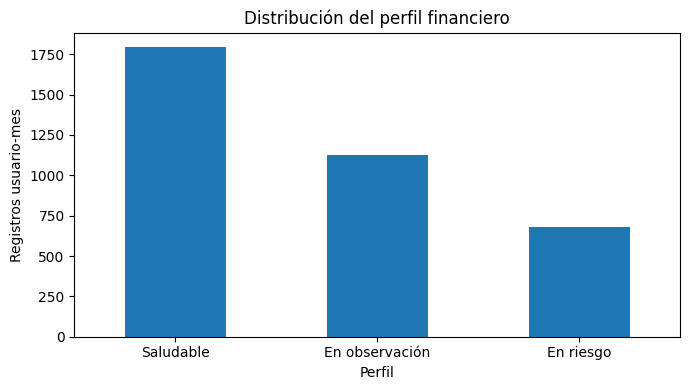

In [ ]:
# Gráfica para revisar el balance de clases

profile_counts = (monthly_financial_summary["perfil_financiero"].value_counts())

plt.figure(figsize=(7, 4))
profile_counts.plot(kind="bar")
plt.title("Distribución del perfil financiero")
plt.xlabel("Perfil")
plt.ylabel("Registros usuario-mes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

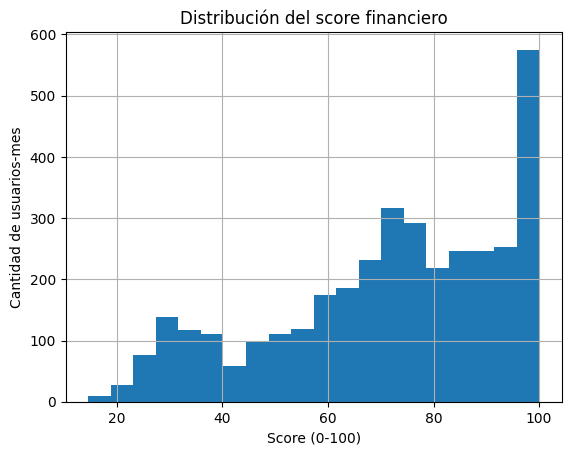

In [ ]:
#Distribución del Score Financiero
monthly_financial_summary["score_financiero"].hist(bins=20)
plt.title("Distribución del score financiero")
plt.xlabel("Score (0-100)")
plt.ylabel("Cantidad de usuarios-mes")
plt.show()

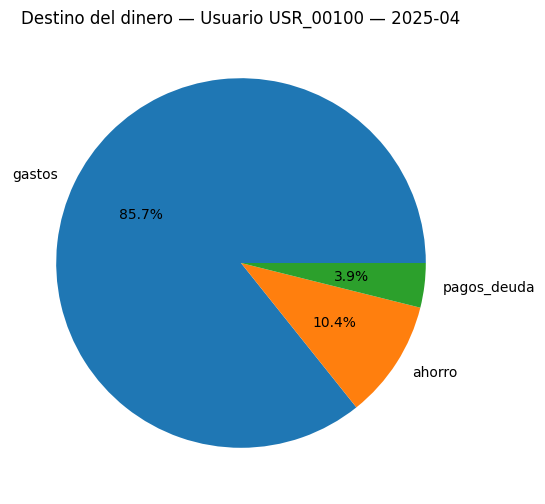

In [ ]:
#Distribución del Dinero por Mes
# Elige un usuario y periodo
user_id_ejemplo = "USR_00100"
periodo_ejemplo = "2025-04"

fila = monthly_financial_summary[
    (monthly_financial_summary["user_id"] == user_id_ejemplo) &
    (monthly_financial_summary["periodo"] == periodo_ejemplo)
]

destino = fila[["gastos", "ahorro", "pagos_deuda", "inversiones"]].iloc[0]
destino = destino[destino > 0]

plt.figure(figsize=(6,6))
plt.pie(destino, labels=destino.index, autopct="%1.1f%%")
plt.title(f"Destino del dinero — Usuario {user_id_ejemplo} — {periodo_ejemplo}")
plt.show()

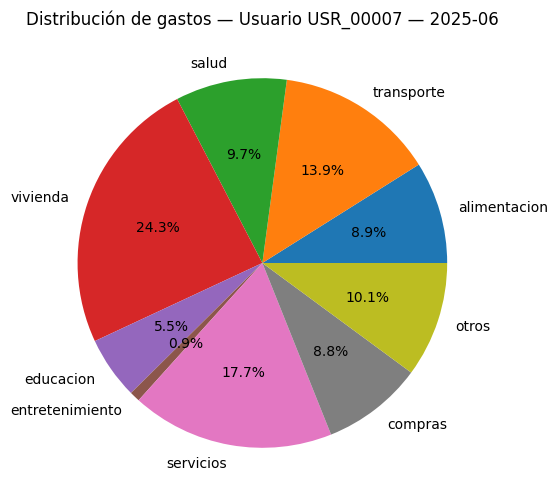

In [ ]:
#Distribucion de gasto por usuario en un mes
user_id_ejemplo = "USR_00007"
periodo_ejemplo = "2025-06"

fila = monthly_financial_summary[
    (monthly_financial_summary["user_id"] == user_id_ejemplo) &
    (monthly_financial_summary["periodo"] == periodo_ejemplo)
]

gastos_categoria = fila[category_amount_columns].iloc[0]
gastos_categoria = gastos_categoria[gastos_categoria > 0]  # solo categorías con gasto
gastos_categoria.index = gastos_categoria.index.str.replace("gasto_", "", regex=False)

plt.figure(figsize=(6,6))
plt.pie(gastos_categoria, labels=gastos_categoria.index, autopct="%1.1f%%")
plt.title(f"Distribución de gastos — Usuario {user_id_ejemplo} — {periodo_ejemplo}")
plt.show()

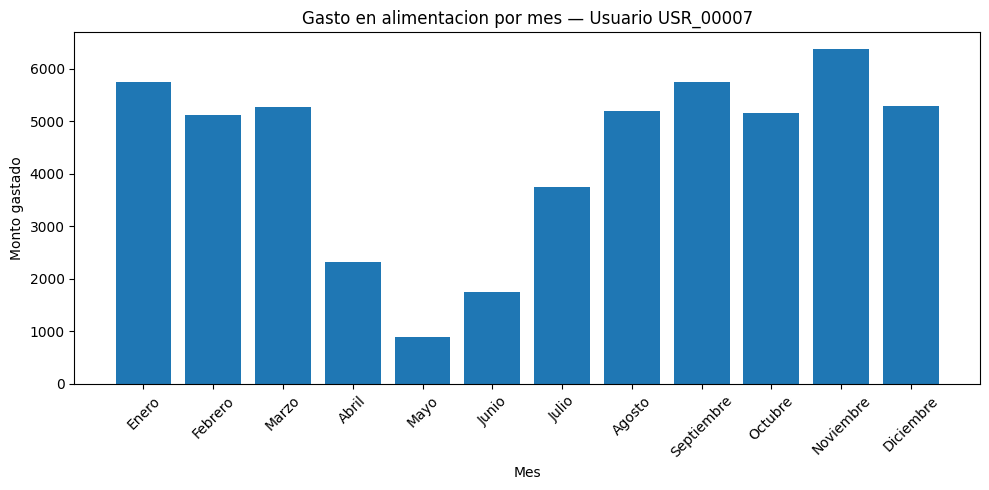

In [ ]:
# Evolucion de Gasto por Categoría
user_id_ejemplo = "USR_00007"
categoria_ejemplo = "alimentacion"

columna_categoria = "gasto_" + categoria_ejemplo

# Filtra todos los meses del mismo usuario
datos_usuario = monthly_financial_summary[
    monthly_financial_summary["user_id"] == user_id_ejemplo
].sort_values("periodo")

plt.figure(figsize=(10,5))
plt.bar(datos_usuario["nombre_mes"], datos_usuario[columna_categoria])
plt.title(f"Gasto en {categoria_ejemplo} por mes — Usuario {user_id_ejemplo}")
plt.xlabel("Mes")
plt.ylabel("Monto gastado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Resultado final

El notebook deja listos:

- El resumen mensual completo y explicable
- El dataset para comenzar la etapa de modelos
- Una auditoría de las clases generadas
- Distribución del Score Financiero, Distribucion del Dinero, Distribucion de Gastos por Categorias y la Evolución de la categoria.